# Artifact Dataset Preprocessing — MR-ART, KMAR & Simulated

This notebook preprocesses **artifact MRI datasets** for:
1. **Testing** all SSL/unsupervised models (SimCLR, MAE, DINO, DAE, PatchCore)
2. **Supervised training** (artifact classifier)
3. **Simulated artifact testing** (separate experiment)

## Datasets
| Dataset | Anatomy | Format | Artifact Type | Use |
|---------|---------|--------|---------------|-----|
| **MR-ART** | Brain | PNG slices | Patient motion | Test + Supervised train |
| **KMAR** | Knee | `.nii` volumes | Patient motion | Test + Supervised train |
| **Simulated (brain tumor)** | Brain | JPG slices | Noise / motion / blur | Test only (Experiment 2) |

## Preprocessing Pipeline (matches SSL training data)
| Input type | Pipeline |
|------------|----------|
| PNG/JPG (MR-ART, simulated) | load → center crop/pad 192×192 → **per-image** p1/p99 → [0,1] → filter mean>0.01 |
| `.nii` volume (KMAR) | load → **center crop (192,192,32)** → **per-volume** p1/p99 → [0,1] → extract all slices with mean>0.01 |

This matches `preprocessing-fastmri-knee` and `preprocessing-ixi-brain` exactly for the volumetric path. For single-slice PNG/JPG input (where no volume exists), percentile is computed per-image — the only sensible choice.

## Test-Set Balancing
MR-ART and KMAR test counts are equalized:
- `N_test_artifact = min(len(mrart_artifact), len(kmar_artifact))`
- `N_test_clean    = min(len(mrart_clean),    len(kmar_clean))`
- Deterministic `linspace` subsampling — same strategy as SSL balanced brain sampling.

## Supervised Training Data Design (3 anatomy variants)

We build **three** supervised datasets so the supervised classifier can be trained per anatomy — mirroring the SSL study (knee-only / brain-only / combined):

| Variant | Clean negatives (label=0) | Artifact positives (label=1) |
|---------|---------------------------|------------------------------|
| **knee**     | SSL knee train/val (FastMRI)              | KMAR only |
| **brain**    | SSL brain train/val (balanced T1+T2 IXI)  | MR-ART only |
| **combined** | SSL knee + brain                          | MR-ART + KMAR (50/50) |

- **Positives count** per variant = `ARTIFACT_RATIO × clean_train_count` (default **7.5%**), 80/20 train/val split.
- **Disk-efficient**: clean .npy files are copied **once** into a shared `supervised_clean_pool/{train,val}/{knee,brain}/` folder. Each variant's `.npz` manifest references the appropriate subset of those files (no duplication).
- **Test sets** (no overlap with supervised training):
  - MR-ART/KMAR artifact: the REMAINDERS after supervised sampling (union across variants)
  - MR-ART/KMAR clean: all balanced clean slices (never used for training)

## Output Structure (fully self-contained → upload as Kaggle dataset)
```
/kaggle/working/artifact_data/
├── test_mrart/{artifact,clean}/         # .npy — balanced MR-ART
├── test_kmar/{artifact,clean}/          # .npy — balanced KMAR
├── test_simulated/{noisy,motion,blurred}/   # .npy — Experiment 2
├── supervised_clean_pool/
│   ├── train/{knee,brain}/              # .npy — copied SSL train (shared)
│   └── val/{knee,brain}/                # .npy — copied SSL val   (shared)
├── supervised_artifacts/
│   ├── train/{mrart,kmar}/              # .npy — copied artifact positives
│   └── val/{mrart,kmar}/                # .npy — copied artifact positives
└── supervised_manifests/                # .npz indexes (paths inside output_root)
    ├── supervised_train_knee.npz     / supervised_val_knee.npz
    ├── supervised_train_brain.npz    / supervised_val_brain.npz
    ├── supervised_train_combined.npz / supervised_val_combined.npz
    ├── test_mrart.npz / test_kmar.npz / test_simulated.npz
```

In [1]:
import os
import gc
import random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from PIL import Image
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Target preprocessing params (MUST match SSL pipeline) ──
IMG_SIZE = 192
MIN_SLICE_MEAN = 0.01       # same as FastMRI/IXI preprocessing
PERCENTILE_LO = 1           # same as FastMRI/IXI preprocessing
PERCENTILE_HI = 99          # same as FastMRI/IXI preprocessing

# ── Output root ──
OUTPUT_ROOT = "/kaggle/working/artifact_data"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print(f"Target size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Normalization: p{PERCENTILE_LO}/p{PERCENTILE_HI} clip → [0, 1]")
print(f"Slice filter: mean > {MIN_SLICE_MEAN}")
print(f"Output: {OUTPUT_ROOT}")

Target size: 192x192
Normalization: p1/p99 clip → [0, 1]
Slice filter: mean > 0.01
Output: /kaggle/working/artifact_data


In [2]:

# Install nibabel for loading .nii volumes (KMAR dataset)
!pip install -q nibabel


In [3]:
# ══════════════════════════════════════════════
# Step 1: Discover all available datasets
# ══════════════════════════════════════════════
INPUT_ROOT = "/kaggle/input"

def scan_directory(root_path, max_files_per_dir=5):
    """Recursively scan and print directory structure."""
    print(f"\nROOT: {root_path}")
    print("=" * 60)
    for root, dirs, files in os.walk(root_path):
        level = root.replace(root_path, '').count(os.sep)
        indent = '  ' * level
        folder_name = os.path.basename(root)
        print(f"{indent}{folder_name}/")
        sub_indent = '  ' * (level + 1)
        if files:
            exts = Counter(os.path.splitext(f)[1].lower() for f in files)
            print(f"{sub_indent}Files: {len(files)} total | Extensions: {dict(exts)}")
            for f in files[:max_files_per_dir]:
                print(f"{sub_indent}  - {f}")
            if len(files) > max_files_per_dir:
                print(f"{sub_indent}  ... ({len(files) - max_files_per_dir} more)")

# List all mounted datasets
datasets = sorted(os.listdir(INPUT_ROOT))
print("AVAILABLE DATASETS:")
print("=" * 60)
for d in datasets:
    full = os.path.join(INPUT_ROOT, d)
    size_info = ""
    try:
        n_files = sum(len(f) for _, _, f in os.walk(full))
        size_info = f" ({n_files} files)"
    except:
        pass
    print(f"  - {d}{size_info}")

AVAILABLE DATASETS:
  - datasets (72328 files)


In [4]:
# Scan each dataset to understand structure
for dataset in datasets:
    dataset_path = os.path.join(INPUT_ROOT, dataset)
    scan_directory(dataset_path, max_files_per_dir=5)


ROOT: /kaggle/input/datasets
datasets/
  derbyfahim/
    438datast/
      KMAR-50K/
        Files: 2 total | Extensions: {'.csv': 2}
          - TestingCohort.csv
          - TrainingCohort.csv
        ArtifactData_part1/
          Files: 698 total | Extensions: {'.nii': 698}
            - 2021_97-XXX_MR3202104110017_transection_0.0.nii
            - 2021_72-XX_MR1202102250174_sagittal_0.0.nii
            - 2021_187-20210618002458_coronal_0.0.nii
            - 2020_11_coronal_0.0.nii
            - 2020_242_transection_0.0.nii
            ... (693 more)
        Testing _GroundTruthData/
          1_GroundTruthData/
            Files: 204 total | Extensions: {'.nii': 204}
              - 2023_47_sagittal_0.0_N4_Norm_RegSyN.nii
              - 2023_70_sagittal_0.0_N4_Norm_RegSyN.nii
              - 2023_44_sagittal_0.0_N4_Norm_RegSyN.nii
              - 2023_33_sagittal_0.0.nii
              - 2023_46_transection_0.0.nii
              ... (199 more)
        GroundTruthData_part1/
       

---
## Configure Dataset Paths

**After running the scan above**, fill in the correct paths below.

Each dataset needs:
- Path to artifact images (motion-corrupted)
- Path to clean images (if available in the same dataset)
- File extension (`.png`, `.jpg`, `.npy`, etc.)

In [5]:

# ══════════════════════════════════════════════════════════════
# Dataset paths (verified from user's Kaggle environment)
# ══════════════════════════════════════════════════════════════

# ── MR-ART (Brain motion artifacts — PNG slices) ──
MRART_ROOT = "/kaggle/input/datasets/mdfaisalkarim/ranged-mrart/Ranged dataset"
MRART_ARTIFACT_DIRS = [
    os.path.join(MRART_ROOT, "headmotion1"),   # 5760 PNGs
    os.path.join(MRART_ROOT, "headmotion2"),   # 2940 PNGs
]
MRART_CLEAN_DIRS = [
    os.path.join(MRART_ROOT, "Standard"),      # 2960 PNGs (clean T1 brain)
]
MRART_EXT = ".png"

# ── KMAR (Knee motion artifacts — .nii volumes) ──
KMAR_ROOT = "/kaggle/input/datasets/derbyfahim/438datast/KMAR-50K"
KMAR_ARTIFACT_DIRS = [
    os.path.join(KMAR_ROOT, "ArtifactData_part1"),            # 698 volumes
]
KMAR_CLEAN_DIRS = [
    os.path.join(KMAR_ROOT, "GroundTruthData_part1"),                             # 700 volumes
    os.path.join(KMAR_ROOT, "Testing _GroundTruthData", "1_GroundTruthData"),     # 204 volumes
]
KMAR_EXT = ".nii"

# ── Simulated Artifacts (Experiment 2 — test only, brain tumor dataset) ──
SIM_ROOT = "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/Challenging Datasets/Challenging Datasets"
# Flatten tumor sub-classes (Pituitary/No-tumor/Meningioma/Glioma) into single artifact folders
SIM_ARTIFACT_DIRS = {
    "noisy":  os.path.join(SIM_ROOT, "Noisy Dataset"),                  # gaussian / salt_pepper / speckle
    "motion": os.path.join(SIM_ROOT, "Patient Motion Artifact Dataset"),
    "blurred": os.path.join(SIM_ROOT, "Blurred Dataset"),               # gaussian / median / bilateral
}
SIM_EXT = ".jpg"

# ── SSL clean data paths (already preprocessed as .npy) ──
# IDENTICAL to the roots used in MAE/DINO/SimCLR/DAE/PatchCore training notebooks.
# Each train/val root contains anatomy/contrast subfolders (KNEE; T1, T2) — the
# same `get_balanced_paths` used in SSL training will pick the same balanced subset.
SSL_KNEE_TRAIN  = "/kaggle/input/datasets/kaustubhratna/fast-mri-preprocessed-kaust/train"
SSL_KNEE_VAL    = "/kaggle/input/datasets/kaustubhratna/fast-mri-preprocessed-kaust/val"
SSL_BRAIN_TRAIN = "/kaggle/input/datasets/kaustubhratna/preprocessed-ixi-brain/train"
SSL_BRAIN_VAL   = "/kaggle/input/datasets/kaustubhratna/preprocessed-ixi-brain/val"

# ── KMAR slice extraction params (match FastMRI/IXI pipeline) ──
KMAR_VOL_TARGET_SHAPE = (192, 192, 32)   # (H, W, Z) — same as FastMRI
KMAR_VOL_MIN_DEPTH    = 20               # skip shallow volumes

# ── Test-set balancing: MR-ART artifact count == KMAR artifact count ──
# Count is auto-determined as min(available MR-ART, available KMAR) after slice extraction.

# ── Supervised positives ratio ──
ARTIFACT_RATIO = 0.075   # 7.5% of SSL clean train count

print("Configuration set. Verifying paths:")
all_paths = {
    "MR-ART root":      MRART_ROOT,
    "KMAR root":        KMAR_ROOT,
    "Simulated root":   SIM_ROOT,
    "SSL Knee train":   SSL_KNEE_TRAIN,
    "SSL Knee val":     SSL_KNEE_VAL,
    "SSL Brain train":  SSL_BRAIN_TRAIN,
    "SSL Brain val":    SSL_BRAIN_VAL,
}
for name, path in all_paths.items():
    status = "OK " if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {name}: {path}")

for d in MRART_ARTIFACT_DIRS + MRART_CLEAN_DIRS + KMAR_ARTIFACT_DIRS + KMAR_CLEAN_DIRS:
    status = "OK " if os.path.exists(d) else "MISSING"
    print(f"  [{status}] {d}")

for atype, d in SIM_ARTIFACT_DIRS.items():
    status = "OK " if os.path.exists(d) else "MISSING"
    print(f"  [{status}] SIM[{atype}]: {d}")


Configuration set. Verifying paths:
  [OK ] MR-ART root: /kaggle/input/datasets/mdfaisalkarim/ranged-mrart/Ranged dataset
  [OK ] KMAR root: /kaggle/input/datasets/derbyfahim/438datast/KMAR-50K
  [OK ] Simulated root: /kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/Challenging Datasets/Challenging Datasets
  [OK ] SSL Knee train: /kaggle/input/datasets/kaustubhratna/fast-mri-preprocessed-kaust/train
  [OK ] SSL Knee val: /kaggle/input/datasets/kaustubhratna/fast-mri-preprocessed-kaust/val
  [OK ] SSL Brain train: /kaggle/input/datasets/kaustubhratna/preprocessed-ixi-brain/train
  [OK ] SSL Brain val: /kaggle/input/datasets/kaustubhratna/preprocessed-ixi-brain/val
  [OK ] /kaggle/input/datasets/mdfaisalkarim/ranged-mrart/Ranged dataset/headmotion1
  [OK ] /kaggle/input/datasets/mdfaisalkarim/ranged-mrart/Ranged dataset/headmotion2
  [OK ] /kaggle/input/datasets/mdfaisalkarim/ranged-mrart/Ranged dataset/Standard
  [OK ] /kaggle/input/datasets/derbyfahim

---
## Core Preprocessing Functions

Matches the SSL preprocessing pipeline:
1. Load image (PNG/JPG/DICOM) → grayscale float32
2. Center crop/pad to 192×192 (no distortion)
3. Percentile normalization: clip to [p1, p99] → scale to [0, 1]
4. Filter: discard if mean < 0.01
5. Save as float32 .npy

In [6]:

# ══════════════════════════════════════════════
# Core Preprocessing (matches SSL pipeline)
# ══════════════════════════════════════════════

try:
    import nibabel as nib
    HAS_NIB = True
except ImportError:
    HAS_NIB = False
    print("WARNING: nibabel not installed. Install with: !pip install nibabel")


def load_image_as_grayscale(path):
    """Load a 2D image (PNG/JPG/NPY) and return float32 grayscale ndarray."""
    ext = os.path.splitext(path)[1].lower()
    if ext == '.npy':
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img.mean(axis=-1)
        return img
    elif ext in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
        img = Image.open(path).convert('L')
        return np.array(img, dtype=np.float32)
    else:
        raise ValueError(f"Unsupported 2D format: {ext}")


def load_nii_volume(path):
    """Load a .nii / .nii.gz volume as float32 ndarray shaped (H, W, Z)."""
    if not HAS_NIB:
        raise RuntimeError("nibabel required for .nii loading")
    vol = nib.load(path).get_fdata().astype(np.float32)
    # Normalize orientation: if last axis is smallest, assume (H, W, Z). Otherwise
    # rotate so smallest dim is last.
    if vol.ndim != 3:
        raise ValueError(f"Expected 3D volume, got {vol.shape}")
    z_axis = int(np.argmin(vol.shape))
    if z_axis != 2:
        vol = np.moveaxis(vol, z_axis, -1)
    return vol


def center_crop_3d(volume, target_shape):
    """Center crop/pad a (H, W, Z) volume to target_shape. Same as FastMRI pipeline."""
    x, y, z = volume.shape
    tx, ty, tz = target_shape
    # Pad if smaller
    pad_x = max(0, tx - x)
    pad_y = max(0, ty - y)
    pad_z = max(0, tz - z)
    if pad_x or pad_y or pad_z:
        volume = np.pad(volume,
                        ((pad_x // 2, pad_x - pad_x // 2),
                         (pad_y // 2, pad_y - pad_y // 2),
                         (pad_z // 2, pad_z - pad_z // 2)),
                        mode='reflect')
        x, y, z = volume.shape
    sx = (x - tx) // 2
    sy = (y - ty) // 2
    sz = (z - tz) // 2
    return volume[sx:sx + tx, sy:sy + ty, sz:sz + tz]


def normalize_volume(volume, p_lo=1, p_hi=99):
    """Per-volume p1/p99 percentile normalization → [0,1] float32.
    IDENTICAL to FastMRI/IXI preprocessing."""
    p1 = np.percentile(volume, p_lo)
    p99 = np.percentile(volume, p_hi)
    if p99 - p1 < 1e-5:
        return None
    volume = np.clip(volume, p1, p99)
    return ((volume - p1) / (p99 - p1)).astype(np.float32)


def center_crop_or_pad(img, target_size=192):
    """2D center crop/pad with reflect padding. For PNG/JPG slice input."""
    h, w = img.shape
    if h < target_size or w < target_size:
        pad_h = max(0, target_size - h)
        pad_w = max(0, target_size - w)
        img = np.pad(img,
                     ((pad_h // 2, pad_h - pad_h // 2),
                      (pad_w // 2, pad_w - pad_w // 2)),
                     mode='reflect')
        h, w = img.shape
    y = (h - target_size) // 2
    x = (w - target_size) // 2
    return img[y:y + target_size, x:x + target_size]


def normalize_percentile_2d(img, p_lo=1, p_hi=99):
    """Per-image p1/p99 percentile normalization → [0,1]. For 2D PNG/JPG input."""
    p1 = np.percentile(img, p_lo)
    p99 = np.percentile(img, p_hi)
    if p99 - p1 < 1e-5:
        return None
    img = np.clip(img, p1, p99)
    return ((img - p1) / (p99 - p1)).astype(np.float32)


def preprocess_2d_image(path, target_size=IMG_SIZE):
    """Full pipeline for a single 2D image (PNG/JPG/NPY).
    Returns (image, True) or (None, False)."""
    try:
        img = load_image_as_grayscale(path)
        img = center_crop_or_pad(img, target_size)
        img = normalize_percentile_2d(img, PERCENTILE_LO, PERCENTILE_HI)
        if img is None or img.mean() < MIN_SLICE_MEAN:
            return None, False
        return img, True
    except Exception as e:
        return None, False


def preprocess_nii_volume(path, target_shape=KMAR_VOL_TARGET_SHAPE,
                          min_depth=KMAR_VOL_MIN_DEPTH):
    """Full pipeline for a .nii volume — IDENTICAL to FastMRI preprocessing.
    Returns list of 2D float32 slices (each 192x192), or [] on failure."""
    try:
        vol = load_nii_volume(path)
        if vol.shape[2] < min_depth:
            return []
        vol = center_crop_3d(vol, target_shape)
        if vol.shape != target_shape:
            return []
        vol = normalize_volume(vol, PERCENTILE_LO, PERCENTILE_HI)
        if vol is None:
            return []
        slices = []
        for i in range(vol.shape[2]):
            sl = vol[:, :, i]
            if np.mean(sl) < MIN_SLICE_MEAN:
                continue
            slices.append(sl.astype(np.float32))
        return slices
    except Exception as e:
        return []


def collect_image_paths(directories, ext=".png"):
    """Collect all files with given extension from directories."""
    paths = []
    ext = ext.lower()
    extras = {ext}
    if ext == '.nii':
        extras.add('.nii.gz')
    for d in directories:
        if not os.path.exists(d):
            print(f"  WARNING: missing directory, skipping: {d}")
            continue
        for root, _, files in os.walk(d):
            for f in sorted(files):
                lf = f.lower()
                if any(lf.endswith(e) for e in extras):
                    paths.append(os.path.join(root, f))
    return sorted(paths)


def process_and_save_2d(input_paths, output_dir, prefix="img"):
    """Preprocess a list of 2D images and save as .npy."""
    os.makedirs(output_dir, exist_ok=True)
    saved, skipped = [], 0
    for i, path in enumerate(tqdm(input_paths, desc=f"→ {os.path.basename(output_dir)}")):
        img, ok = preprocess_2d_image(path)
        if not ok:
            skipped += 1
            continue
        stem = os.path.splitext(os.path.basename(path))[0]
        save_path = os.path.join(output_dir, f"{prefix}_{stem}_{i:05d}.npy")
        np.save(save_path, img)
        saved.append(save_path)
    print(f"  Saved: {len(saved)} | Skipped: {skipped} | Input: {len(input_paths)}")
    return saved


def process_and_save_nii(input_paths, output_dir, prefix="vol"):
    """Preprocess a list of .nii volumes, extract slices, and save as .npy."""
    os.makedirs(output_dir, exist_ok=True)
    saved, processed_vols, skipped_vols = [], 0, 0
    for path in tqdm(input_paths, desc=f"→ {os.path.basename(output_dir)}"):
        slices = preprocess_nii_volume(path)
        if not slices:
            skipped_vols += 1
            continue
        stem = os.path.splitext(os.path.basename(path))[0]
        if stem.endswith('.nii'):
            stem = stem[:-4]
        for s_idx, sl in enumerate(slices):
            save_path = os.path.join(output_dir, f"{prefix}_{stem}_slice_{s_idx:03d}.npy")
            np.save(save_path, sl)
            saved.append(save_path)
        processed_vols += 1
    print(f"  Volumes processed: {processed_vols} | Skipped: {skipped_vols}")
    print(f"  Total slices saved: {len(saved)}")
    return saved


# Quick tests
print("Preprocessing functions ready.")
_test = np.random.rand(256, 300).astype(np.float32) * 255
_result = center_crop_or_pad(_test, 192)
assert _result.shape == (192, 192)
_norm = normalize_percentile_2d(_result)
assert _norm.min() >= 0 and _norm.max() <= 1.0
print(f"  2D test: {_test.shape} → {_result.shape} → range [{_norm.min():.2f}, {_norm.max():.2f}]")

_vol = np.random.rand(240, 260, 35).astype(np.float32) * 1000
_vc = center_crop_3d(_vol, (192, 192, 32))
assert _vc.shape == (192, 192, 32)
_vn = normalize_volume(_vc)
assert _vn is not None and _vn.min() >= 0 and _vn.max() <= 1.0
print(f"  3D test: {_vol.shape} → {_vc.shape} → range [{_vn.min():.2f}, {_vn.max():.2f}]")
del _test, _result, _norm, _vol, _vc, _vn


Preprocessing functions ready.
  2D test: (256, 300) → (192, 192) → range [0.00, 1.00]
  3D test: (240, 260, 35) → (192, 192, 32) → range [0.00, 1.00]


In [7]:
# ══════════════════════════════════════════════
# Balanced Brain Sampling (same as SSL notebooks)
# ══════════════════════════════════════════════

def get_balanced_paths(root_dir, target_total=None):
    """Deterministic balanced subsampling — IDENTICAL to MAE/DINO/SimCLR/DAE/PatchCore."""
    groups = {}
    for dirpath, _, filenames in os.walk(root_dir):
        npy_files = sorted(f for f in filenames if f.endswith('.npy'))
        if npy_files:
            folder = os.path.basename(dirpath)
            groups[folder] = [os.path.join(dirpath, f) for f in npy_files]

    if not groups:
        return [], []

    if target_total is None:
        paths, labels = [], []
        for folder in sorted(groups):
            paths.extend(groups[folder])
            labels.extend([folder] * len(groups[folder]))
        return paths, labels

    n_groups = len(groups)
    target_per_group = target_total // n_groups

    paths, labels = [], []
    for folder in sorted(groups):
        group_paths = groups[folder]
        if len(group_paths) <= target_per_group:
            selected = group_paths
        else:
            idx = np.round(np.linspace(0, len(group_paths) - 1, target_per_group)).astype(int)
            selected = [group_paths[i] for i in idx]
        paths.extend(selected)
        labels.extend([folder] * len(selected))
        print(f"    {folder}: {len(selected)}/{len(group_paths)} selected")

    return paths, labels

print("Balanced sampling function ready (identical to SSL notebooks).")

Balanced sampling function ready (identical to SSL notebooks).


---
# Part 1: Process MR-ART (Brain Motion Artifacts)

Collects artifact and clean images from MR-ART dataset.
- **Artifact images** → `test_mrart/artifact/` (for SSL model testing)
- **Clean images** → `test_mrart/clean/` (for paired evaluation)

In [8]:

# ══════════════════════════════════════════════
# Process MR-ART (PNG slices, 2D)
# ══════════════════════════════════════════════
print("="*60)
print("MR-ART: Brain Motion Artifacts (PNG slices)")
print("="*60)

mrart_artifact_paths_raw = collect_image_paths(MRART_ARTIFACT_DIRS, MRART_EXT)
mrart_clean_paths_raw = collect_image_paths(MRART_CLEAN_DIRS, MRART_EXT)
print(f"  Artifact images found: {len(mrart_artifact_paths_raw)} (headmotion1 + headmotion2)")
print(f"  Clean images found:    {len(mrart_clean_paths_raw)} (Standard)")

# Process artifacts
print("\nProcessing MR-ART artifact PNGs...")
mrart_artifact_saved = process_and_save_2d(
    mrart_artifact_paths_raw,
    os.path.join(OUTPUT_ROOT, "test_mrart", "artifact"),
    prefix="mrart_art",
)

# Process clean
print("\nProcessing MR-ART clean PNGs...")
mrart_clean_saved = process_and_save_2d(
    mrart_clean_paths_raw,
    os.path.join(OUTPUT_ROOT, "test_mrart", "clean"),
    prefix="mrart_cln",
)

print(f"\nMR-ART summary:")
print(f"  Artifact: {len(mrart_artifact_saved)} preprocessed slices")
print(f"  Clean:    {len(mrart_clean_saved)} preprocessed slices")


MR-ART: Brain Motion Artifacts (PNG slices)
  Artifact images found: 8700 (headmotion1 + headmotion2)
  Clean images found:    2960 (Standard)

Processing MR-ART artifact PNGs...


→ artifact: 100%|██████████| 8700/8700 [01:03<00:00, 136.63it/s]


  Saved: 8700 | Skipped: 0 | Input: 8700

Processing MR-ART clean PNGs...


→ clean: 100%|██████████| 2960/2960 [00:20<00:00, 143.81it/s]

  Saved: 2960 | Skipped: 0 | Input: 2960

MR-ART summary:
  Artifact: 8700 preprocessed slices
  Clean:    2960 preprocessed slices


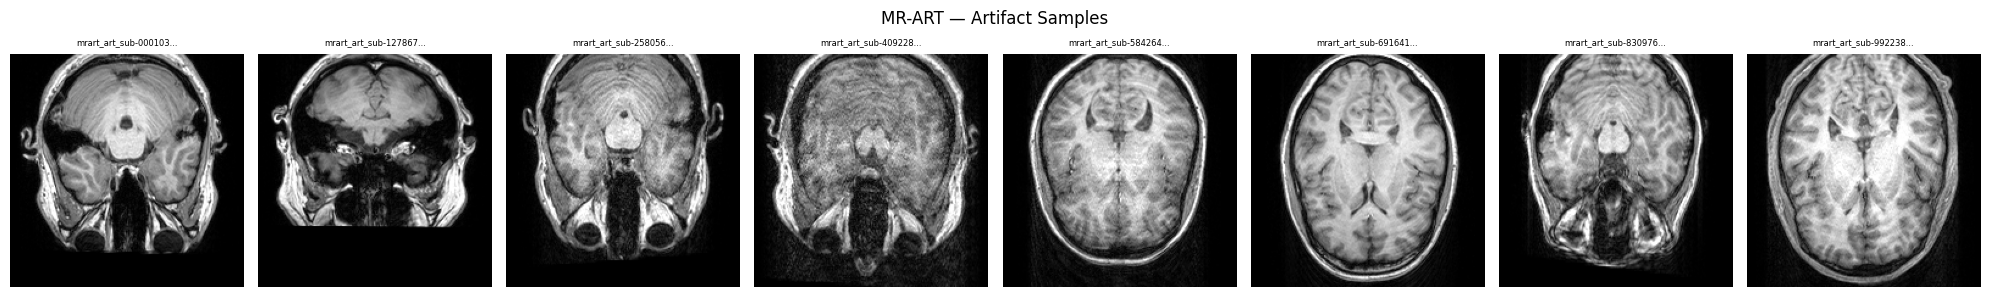

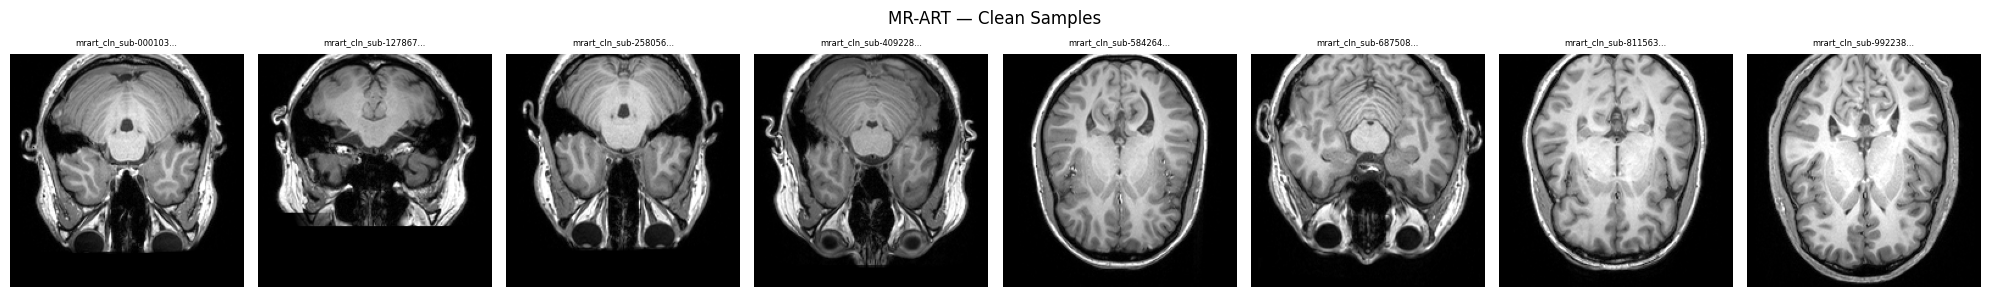

In [9]:
# ── MR-ART Preview ──
def preview_samples(directory, title, n=8):
    files = sorted([f for f in os.listdir(directory) if f.endswith('.npy')])
    if len(files) == 0:
        print(f"No files in {directory}")
        return
    n = min(n, len(files))
    indices = np.round(np.linspace(0, len(files)-1, n)).astype(int)
    fig, axes = plt.subplots(1, n, figsize=(2.5*n, 3))
    if n == 1:
        axes = [axes]
    for i, idx in enumerate(indices):
        img = np.load(os.path.join(directory, files[idx]))
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f"{files[idx][:20]}...", fontsize=6)
        axes[i].axis('off')
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()

preview_samples(os.path.join(OUTPUT_ROOT, "test_mrart", "artifact"), "MR-ART — Artifact Samples")
preview_samples(os.path.join(OUTPUT_ROOT, "test_mrart", "clean"), "MR-ART — Clean Samples")

---
# Part 2: Process KMAR (Knee Motion Artifacts)

In [10]:

# ══════════════════════════════════════════════
# Process KMAR (.nii volumes → 2D slices)
# ══════════════════════════════════════════════
# Uses the SAME pipeline as FastMRI preprocessing:
#   1. center crop to (192, 192, 32)
#   2. per-volume p1/p99 normalization → [0, 1]
#   3. keep only slices with mean > 0.01
print("="*60)
print("KMAR: Knee Motion Artifacts (.nii volumes)")
print("="*60)

kmar_artifact_paths_raw = collect_image_paths(KMAR_ARTIFACT_DIRS, KMAR_EXT)
kmar_clean_paths_raw = collect_image_paths(KMAR_CLEAN_DIRS, KMAR_EXT)
print(f"  Artifact volumes found: {len(kmar_artifact_paths_raw)}")
print(f"  Clean volumes found:    {len(kmar_clean_paths_raw)}")

# Process artifact volumes → slices
print("\nProcessing KMAR artifact volumes...")
kmar_artifact_saved = process_and_save_nii(
    kmar_artifact_paths_raw,
    os.path.join(OUTPUT_ROOT, "test_kmar", "artifact"),
    prefix="kmar_art",
)

# Process clean volumes → slices
print("\nProcessing KMAR clean volumes...")
kmar_clean_saved = process_and_save_nii(
    kmar_clean_paths_raw,
    os.path.join(OUTPUT_ROOT, "test_kmar", "clean"),
    prefix="kmar_cln",
)

print(f"\nKMAR summary:")
print(f"  Artifact: {len(kmar_artifact_saved)} preprocessed slices "
      f"(from {len(kmar_artifact_paths_raw)} volumes)")
print(f"  Clean:    {len(kmar_clean_saved)} preprocessed slices "
      f"(from {len(kmar_clean_paths_raw)} volumes)")


KMAR: Knee Motion Artifacts (.nii volumes)
  Artifact volumes found: 698
  Clean volumes found:    904

Processing KMAR artifact volumes...


→ artifact: 100%|██████████| 698/698 [03:38<00:00,  3.19it/s]


  Volumes processed: 683 | Skipped: 15
  Total slices saved: 21855

Processing KMAR clean volumes...


→ clean: 100%|██████████| 904/904 [05:19<00:00,  2.83it/s]

  Volumes processed: 891 | Skipped: 13
  Total slices saved: 28502

KMAR summary:
  Artifact: 21855 preprocessed slices (from 698 volumes)
  Clean:    28502 preprocessed slices (from 904 volumes)


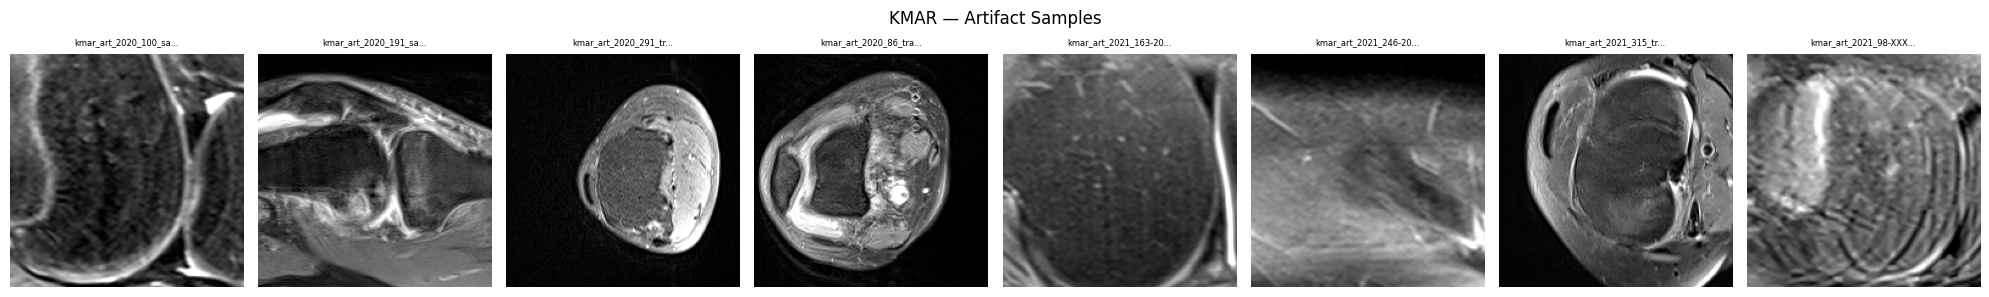

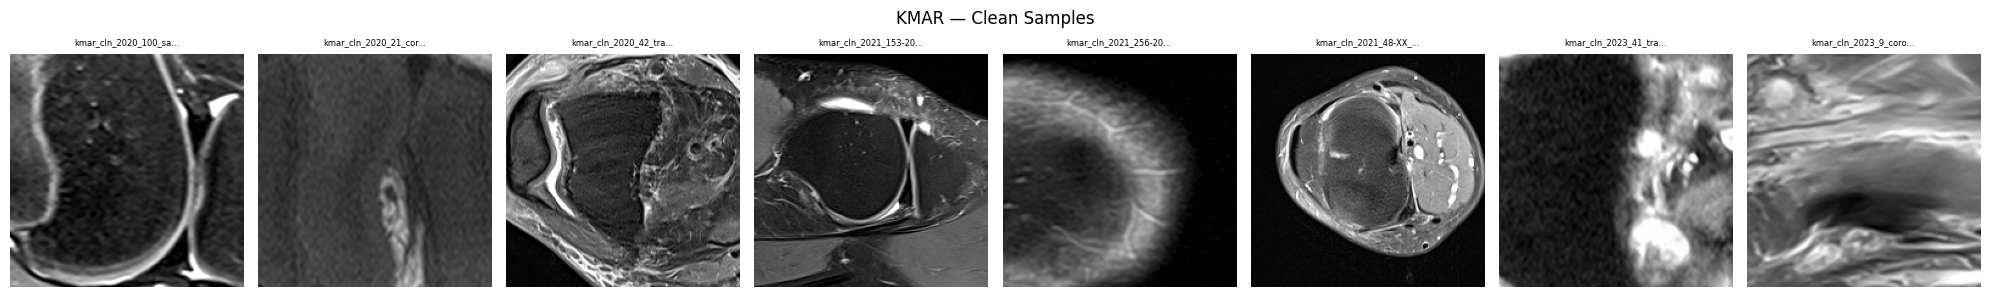

In [11]:
preview_samples(os.path.join(OUTPUT_ROOT, "test_kmar", "artifact"), "KMAR — Artifact Samples")
preview_samples(os.path.join(OUTPUT_ROOT, "test_kmar", "clean"), "KMAR — Clean Samples")


---
# Part 2b: Balance MR-ART and KMAR Test Sets

To make MR-ART and KMAR directly comparable in evaluation, we subsample the
LARGER of each pair down to the count of the smaller one:

- `N_test_artifact = min(len(mrart_artifact), len(kmar_artifact))`
- `N_test_clean    = min(len(mrart_clean),    len(kmar_clean))`

Deterministic (`np.round(np.linspace(...))`) subsampling — same strategy as
the balanced brain sampling used in all SSL notebooks. Files that are NOT
selected are **deleted from disk** so the output directories always reflect
what will be shipped in the final Kaggle dataset.


In [12]:

# ══════════════════════════════════════════════
# Balance MR-ART and KMAR (same count for both)
# ══════════════════════════════════════════════

def deterministic_subsample(paths, target):
    """Pick `target` paths evenly spaced from sorted paths. Deletes the
    un-selected ones from disk so output dir matches manifest."""
    paths = sorted(paths)
    if len(paths) <= target:
        return paths
    idx = np.round(np.linspace(0, len(paths) - 1, target)).astype(int)
    idx = np.unique(idx)            # guard against duplicates at small N
    keep_set = {paths[i] for i in idx}
    removed = 0
    for p in paths:
        if p not in keep_set:
            try:
                os.remove(p)
                removed += 1
            except OSError:
                pass
    print(f"    kept {len(keep_set)} / {len(paths)} (removed {removed} files)")
    return sorted(keep_set)


# Target counts = min(MR-ART, KMAR) for each of {artifact, clean}
N_TEST_ARTIFACT = min(len(mrart_artifact_saved), len(kmar_artifact_saved))
N_TEST_CLEAN    = min(len(mrart_clean_saved),    len(kmar_clean_saved))

print(f"Balancing target counts:")
print(f"  Artifact per dataset: {N_TEST_ARTIFACT}")
print(f"  Clean per dataset:    {N_TEST_CLEAN}")

print("\n[MR-ART] Balancing artifact...")
mrart_artifact_saved = deterministic_subsample(mrart_artifact_saved, N_TEST_ARTIFACT)
print("[MR-ART] Balancing clean...")
mrart_clean_saved    = deterministic_subsample(mrart_clean_saved,    N_TEST_CLEAN)

print("\n[KMAR] Balancing artifact...")
kmar_artifact_saved  = deterministic_subsample(kmar_artifact_saved,  N_TEST_ARTIFACT)
print("[KMAR] Balancing clean...")
kmar_clean_saved     = deterministic_subsample(kmar_clean_saved,     N_TEST_CLEAN)

print(f"\nAfter balancing:")
print(f"  MR-ART artifact: {len(mrart_artifact_saved)} | clean: {len(mrart_clean_saved)}")
print(f"  KMAR   artifact: {len(kmar_artifact_saved)} | clean: {len(kmar_clean_saved)}")
assert len(mrart_artifact_saved) == len(kmar_artifact_saved)
assert len(mrart_clean_saved)    == len(kmar_clean_saved)


Balancing target counts:
  Artifact per dataset: 8700
  Clean per dataset:    2960

[MR-ART] Balancing artifact...
[MR-ART] Balancing clean...

[KMAR] Balancing artifact...
    kept 8700 / 21855 (removed 13155 files)
[KMAR] Balancing clean...
    kept 2960 / 28502 (removed 25542 files)

After balancing:
  MR-ART artifact: 8700 | clean: 2960
  KMAR   artifact: 8700 | clean: 2960


---
# Part 3: Process Simulated Artifacts (Experiment 2 — Test Only)

These are **not** used for supervised training. Separate experiment to evaluate
how well models generalize to artifact types not seen during training.

In [13]:

# ══════════════════════════════════════════════
# Process Simulated Artifacts (JPG images)
# ══════════════════════════════════════════════
# Dataset structure: SIM_ROOT/{noisy,motion,blurred}/{tumor_class}/*.jpg
# We flatten tumor classes (Pituitary/No-tumor/Meningioma/Glioma) into a single
# folder per artifact type. Tumor class is NOT a label we care about here —
# only the artifact type matters.
print("="*60)
print("Simulated Artifacts (Experiment 2 — test only)")
print("="*60)

sim_saved = {}
for artifact_type, artifact_dir in SIM_ARTIFACT_DIRS.items():
    print(f"\n  Processing: {artifact_type}")
    if not os.path.exists(artifact_dir):
        print(f"    WARNING: missing {artifact_dir}, skipping")
        sim_saved[artifact_type] = []
        continue

    # Recursive collection — walks into tumor sub-class folders
    paths = collect_image_paths([artifact_dir], SIM_EXT)
    print(f"    Found: {len(paths)} images across tumor sub-classes")

    saved = process_and_save_2d(
        paths,
        os.path.join(OUTPUT_ROOT, "test_simulated", artifact_type),
        prefix=f"sim_{artifact_type}",
    )
    sim_saved[artifact_type] = saved

print(f"\nSimulated artifacts summary:")
for atype, saved in sim_saved.items():
    print(f"  {atype}: {len(saved)} slices")
print(f"  Total: {sum(len(v) for v in sim_saved.values())} slices")


Simulated Artifacts (Experiment 2 — test only)

  Processing: noisy
    Found: 1677 images across tumor sub-classes


→ noisy: 100%|██████████| 1677/1677 [00:10<00:00, 166.06it/s]


  Saved: 1677 | Skipped: 0 | Input: 1677

  Processing: motion
    Found: 559 images across tumor sub-classes


→ motion: 100%|██████████| 559/559 [00:02<00:00, 187.72it/s]


  Saved: 559 | Skipped: 0 | Input: 559

  Processing: blurred
    Found: 1677 images across tumor sub-classes


→ blurred: 100%|██████████| 1677/1677 [00:10<00:00, 167.61it/s]

  Saved: 1677 | Skipped: 0 | Input: 1677

Simulated artifacts summary:
  noisy: 1677 slices
  motion: 559 slices
  blurred: 1677 slices
  Total: 3913 slices


---
# Part 4: Create Supervised Training Datasets (3 variants)

## Design — knee / brain / combined
For each of the three anatomy variants we build train+val splits using the **same preprocessed** SSL clean data and **disjoint** artifact pools:

| Variant | Clean source | Artifact source |
|---------|-------------|-----------------|
| `knee`     | SSL knee (FastMRI)    | KMAR    |
| `brain`    | SSL brain (IXI T1+T2) | MR-ART  |
| `combined` | knee + brain          | MR-ART + KMAR (50/50) |

- **Positives per variant** = `ARTIFACT_RATIO (7.5%) × clean_train_count` for that variant, 80/20 train/val split.
- **Clean files** are copied **once** to a shared `supervised_clean_pool/` to avoid 3× duplication (~10 GB savings).
- **Artifact files** are copied to `supervised_artifacts/{train,val}/{mrart,kmar}/`. Each variant's manifest references the subset it needs.
- **Test artifact remainders** = union of all artifacts NOT used in any variant (so a sample picked only by `combined` is still excluded from the test set).
- All sampling is deterministic (`SEED=42`).

In [14]:

# ══════════════════════════════════════════════
# Build Supervised Datasets — knee / brain / combined
# ══════════════════════════════════════════════
import shutil

print("="*60)
print("Supervised Training Dataset Construction (3 variants)")
print("="*60)

# ── 1. SSL clean data (negatives — SAME as SSL training) ──
print("\n[1] SSL clean data (SAME paths used by all SSL models):")
print("  Knee (all):")
ssl_knee_train, _ = get_balanced_paths(SSL_KNEE_TRAIN)
ssl_knee_val, _   = get_balanced_paths(SSL_KNEE_VAL)
print(f"    Train: {len(ssl_knee_train)} | Val: {len(ssl_knee_val)}")

print(f"  Brain (balanced to match knee = {len(ssl_knee_train)}):")
print("    Train:")
ssl_brain_train, _ = get_balanced_paths(SSL_BRAIN_TRAIN, target_total=len(ssl_knee_train))
print("    Val:")
ssl_brain_val, _   = get_balanced_paths(SSL_BRAIN_VAL,   target_total=len(ssl_knee_val))
print(f"    Train: {len(ssl_brain_train)} | Val: {len(ssl_brain_val)}")

# ── 2. Per-variant artifact budgets (7.5% of that variant's clean train) ──
def even_budget(n_clean, ratio):
    n = max(2, int(n_clean * ratio))
    if n % 2 == 1:
        n += 1
    return n

knee_budget_total     = max(2, int(len(ssl_knee_train)                       * ARTIFACT_RATIO))
brain_budget_total    = max(2, int(len(ssl_brain_train)                      * ARTIFACT_RATIO))
combined_budget_total = even_budget(len(ssl_knee_train) + len(ssl_brain_train), ARTIFACT_RATIO)
combined_half         = combined_budget_total // 2

print(f"\n[2] Artifact budgets ({ARTIFACT_RATIO*100:.1f}% of each variant's clean train):")
print(f"    knee     : {knee_budget_total} (all from KMAR)")
print(f"    brain    : {brain_budget_total} (all from MR-ART)")
print(f"    combined : {combined_budget_total} ({combined_half} MR-ART + {combined_half} KMAR)")

# ── 3. Deterministic sampling helpers ──
def pick_indices(n_total, n_pick):
    """Evenly-spaced indices, deduped, padded to exact n_pick if possible."""
    if n_pick >= n_total:
        return list(range(n_total))
    idx = np.round(np.linspace(0, n_total - 1, n_pick)).astype(int)
    idx = np.unique(idx).tolist()
    if len(idx) < n_pick:
        extras = [i for i in range(n_total) if i not in set(idx)]
        idx = sorted(idx + extras[:n_pick - len(idx)])
    return idx

def pick_paths(paths, n_pick):
    paths = sorted(paths)
    idx = pick_indices(len(paths), n_pick)
    return [paths[i] for i in idx]

# Sample artifacts per source. combined re-uses the knee/brain samples plus
# extra picks if its half exceeds the per-variant count, but to keep things
# simple and disjoint we just sample combined INDEPENDENTLY from each pool.
mrart_brain_sup    = pick_paths(mrart_artifact_saved, brain_budget_total)
kmar_knee_sup      = pick_paths(kmar_artifact_saved,  knee_budget_total)
mrart_combined_sup = pick_paths(mrart_artifact_saved, combined_half)
kmar_combined_sup  = pick_paths(kmar_artifact_saved,  combined_half)

# Union of EVERY artifact used by ANY variant — these must all be excluded from test
used_mrart = sorted(set(mrart_brain_sup) | set(mrart_combined_sup))
used_kmar  = sorted(set(kmar_knee_sup)   | set(kmar_combined_sup))
mrart_test_artifact = [p for p in mrart_artifact_saved if p not in set(used_mrart)]
kmar_test_artifact  = [p for p in kmar_artifact_saved  if p not in set(used_kmar)]

print(f"\n[3] Sampled (per-variant, deterministic):")
print(f"    knee     ← KMAR  : {len(kmar_knee_sup)}")
print(f"    brain    ← MR-ART: {len(mrart_brain_sup)}")
print(f"    combined ← MR-ART: {len(mrart_combined_sup)} | KMAR: {len(kmar_combined_sup)}")
print(f"    Total unique used  — MR-ART: {len(used_mrart)} | KMAR: {len(used_kmar)}")
print(f"    Test remainders    — MR-ART: {len(mrart_test_artifact)} | KMAR: {len(kmar_test_artifact)}")

# ── 4. 80/20 split for each variant (shuffled with shared seed) ──
def shuffled_split(items, seed=SEED):
    items = sorted(items)
    rng = random.Random(seed)
    rng.shuffle(items)
    cut = int(0.8 * len(items))
    return items[:cut], items[cut:]

knee_art_train_src,     knee_art_val_src     = shuffled_split(kmar_knee_sup,                       seed=SEED + 1)
brain_art_train_src,    brain_art_val_src    = shuffled_split(mrart_brain_sup,                     seed=SEED + 2)
combined_art_train_src, combined_art_val_src = shuffled_split(mrart_combined_sup + kmar_combined_sup, seed=SEED + 3)

print(f"\n[4] 80/20 train/val splits:")
print(f"    knee     : {len(knee_art_train_src)} / {len(knee_art_val_src)}")
print(f"    brain    : {len(brain_art_train_src)} / {len(brain_art_val_src)}")
print(f"    combined : {len(combined_art_train_src)} / {len(combined_art_val_src)}")

# ── 5. Copy artifact .npy files into supervised_artifacts/{train,val}/{mrart,kmar}/ ──
SUP_ART_ROOT = os.path.join(OUTPUT_ROOT, "supervised_artifacts")
SUP_ART_TRAIN_MRART = os.path.join(SUP_ART_ROOT, "train", "mrart")
SUP_ART_TRAIN_KMAR  = os.path.join(SUP_ART_ROOT, "train", "kmar")
SUP_ART_VAL_MRART   = os.path.join(SUP_ART_ROOT, "val",   "mrart")
SUP_ART_VAL_KMAR    = os.path.join(SUP_ART_ROOT, "val",   "kmar")
for d in (SUP_ART_TRAIN_MRART, SUP_ART_TRAIN_KMAR, SUP_ART_VAL_MRART, SUP_ART_VAL_KMAR):
    os.makedirs(d, exist_ok=True)

def route_dst(src_path, split):
    """Pick the (train|val) × (mrart|kmar) destination dir."""
    base = os.path.basename(src_path)
    is_mrart = base.startswith("mrart_")
    if split == "train":
        return SUP_ART_TRAIN_MRART if is_mrart else SUP_ART_TRAIN_KMAR
    return SUP_ART_VAL_MRART if is_mrart else SUP_ART_VAL_KMAR

def copy_artifacts(src_paths, split):
    """Copy each .npy ONCE (dedup across variants) into split dir. Returns map src → dst."""
    out = {}
    for p in src_paths:
        if p in out:
            continue
        dst = os.path.join(route_dst(p, split), os.path.basename(p))
        if not os.path.exists(dst):
            shutil.copy2(p, dst)
        out[p] = dst
    return out

# Union per split across all 3 variants → copy each file at most once
all_train_art_srcs = sorted(set(knee_art_train_src) | set(brain_art_train_src) | set(combined_art_train_src))
all_val_art_srcs   = sorted(set(knee_art_val_src)   | set(brain_art_val_src)   | set(combined_art_val_src))

print(f"\n[5] Copying artifact .npy files (deduped across variants):")
src2dst_train = copy_artifacts(all_train_art_srcs, "train")
src2dst_val   = copy_artifacts(all_val_art_srcs,   "val")
print(f"    train artifacts on disk: {len(src2dst_train)}")
print(f"    val   artifacts on disk: {len(src2dst_val)}")

# ── 5b. Remove supervised-used source files from test_mrart/test_kmar folders ──
# Otherwise the on-disk test folders would still contain files that are also
# in supervised_artifacts/, creating a leakage hazard for any downstream code
# that globs the folder directly instead of reading the manifest.
all_used_sources = set(used_mrart) | set(used_kmar)
removed_from_test = 0
for src in all_used_sources:
    if os.path.exists(src):
        try:
            os.remove(src)
            removed_from_test += 1
        except OSError:
            pass
print(f"    Removed {removed_from_test} supervised-used files from test_mrart/test_kmar folders")
print(f"    (manifest paths are unaffected; they point to supervised_artifacts/...)")

def map_to_dst(src_list, src2dst):
    return [src2dst[p] for p in src_list]

# Per-variant destination paths (these go into manifests)
knee_art_train     = map_to_dst(knee_art_train_src,     src2dst_train)
knee_art_val       = map_to_dst(knee_art_val_src,       src2dst_val)
brain_art_train    = map_to_dst(brain_art_train_src,    src2dst_train)
brain_art_val      = map_to_dst(brain_art_val_src,      src2dst_val)
combined_art_train = map_to_dst(combined_art_train_src, src2dst_train)
combined_art_val   = map_to_dst(combined_art_val_src,   src2dst_val)

# ── 6. Final stats ──
def ratio(n_art, n_clean):
    return 100.0 * n_art / max(1, n_art + n_clean)

print(f"\n{'='*60}")
print("SUPERVISED DATASET SUMMARY (3 variants @ 7.5%)")
print(f"{'='*60}")
for name, n_clean_tr, n_clean_va, n_art_tr, n_art_va in [
    ("knee",     len(ssl_knee_train),                       len(ssl_knee_val),                       len(knee_art_train),     len(knee_art_val)),
    ("brain",    len(ssl_brain_train),                      len(ssl_brain_val),                      len(brain_art_train),    len(brain_art_val)),
    ("combined", len(ssl_knee_train)+len(ssl_brain_train),  len(ssl_knee_val)+len(ssl_brain_val),    len(combined_art_train), len(combined_art_val)),
]:
    print(f"  {name:<9} TRAIN clean={n_clean_tr:>6} art={n_art_tr:>4} ({ratio(n_art_tr, n_clean_tr):.2f}%)  "
          f"VAL clean={n_clean_va:>5} art={n_art_va:>3} ({ratio(n_art_va, n_clean_va):.2f}%)")


Supervised Training Dataset Construction (3 variants)

[1] SSL clean data (SAME paths used by all SSL models):
  Knee (all):
    Train: 12864 | Val: 3264
  Brain (balanced to match knee = 12864):
    Train:
    T1: 6432/12800 selected
    T2: 6432/12800 selected
    Val:
    T1: 1632/3200 selected
    T2: 1632/3200 selected
    Train: 12864 | Val: 3264

[2] Artifact budgets (7.5% of each variant's clean train):
    knee     : 964 (all from KMAR)
    brain    : 964 (all from MR-ART)
    combined : 1930 (965 MR-ART + 965 KMAR)

[3] Sampled (per-variant, deterministic):
    knee     ← KMAR  : 964
    brain    ← MR-ART: 964
    combined ← MR-ART: 965 | KMAR: 965
    Total unique used  — MR-ART: 1819 | KMAR: 1819
    Test remainders    — MR-ART: 6881 | KMAR: 6881

[4] 80/20 train/val splits:
    knee     : 771 / 193
    brain    : 771 / 193
    combined : 1544 / 386

[5] Copying artifact .npy files (deduped across variants):
    train artifacts on disk: 2930
    val   artifacts on disk: 764

In [15]:

# ══════════════════════════════════════════════
# Copy SSL clean .npy files into shared pool (used by all 3 variants)
# ══════════════════════════════════════════════
# Layout: supervised_clean_pool/{train,val}/{knee,brain}/*.npy
# Each file is copied EXACTLY ONCE; per-variant manifests reference the
# appropriate subset (knee-only / brain-only / knee+brain).
SUP_CLEAN_ROOT = os.path.join(OUTPUT_ROOT, "supervised_clean_pool")
SUP_CLN_TRAIN_KNEE  = os.path.join(SUP_CLEAN_ROOT, "train", "knee")
SUP_CLN_TRAIN_BRAIN = os.path.join(SUP_CLEAN_ROOT, "train", "brain")
SUP_CLN_VAL_KNEE    = os.path.join(SUP_CLEAN_ROOT, "val",   "knee")
SUP_CLN_VAL_BRAIN   = os.path.join(SUP_CLEAN_ROOT, "val",   "brain")
for d in (SUP_CLN_TRAIN_KNEE, SUP_CLN_TRAIN_BRAIN, SUP_CLN_VAL_KNEE, SUP_CLN_VAL_BRAIN):
    os.makedirs(d, exist_ok=True)

def copy_clean(src_paths, dst_dir, prefix):
    copied = []
    for p in tqdm(src_paths, desc=f"→ {prefix}"):
        dst = os.path.join(dst_dir, f"{prefix}_{os.path.basename(p)}")
        if not os.path.exists(dst):
            shutil.copy2(p, dst)
        copied.append(dst)
    return copied

print("Copying SSL clean → supervised_clean_pool/ (shared across all 3 variants):")
clean_train_knee_dst  = copy_clean(ssl_knee_train,  SUP_CLN_TRAIN_KNEE,  "knee")
clean_train_brain_dst = copy_clean(ssl_brain_train, SUP_CLN_TRAIN_BRAIN, "brain")
clean_val_knee_dst    = copy_clean(ssl_knee_val,    SUP_CLN_VAL_KNEE,    "knee")
clean_val_brain_dst   = copy_clean(ssl_brain_val,   SUP_CLN_VAL_BRAIN,   "brain")

print(f"  train/knee : {len(clean_train_knee_dst)}")
print(f"  train/brain: {len(clean_train_brain_dst)}")
print(f"  val/knee   : {len(clean_val_knee_dst)}")
print(f"  val/brain  : {len(clean_val_brain_dst)}")

# Per-variant clean path lists (these go into manifests)
clean_train_combined = clean_train_knee_dst + clean_train_brain_dst
clean_val_combined   = clean_val_knee_dst   + clean_val_brain_dst


Copying SSL clean → supervised_clean_pool/ (shared across all 3 variants):


→ brain: 100%|██████████| 3264/3264 [00:24<00:00, 134.49it/s]

  train/knee : 12864
  train/brain: 12864
  val/knee   : 3264
  val/brain  : 3264


In [16]:

# ══════════════════════════════════════════════
# Save Supervised Dataset Manifests (3 variants × {train, val})
# ══════════════════════════════════════════════
# All paths point INSIDE OUTPUT_ROOT so the manifests remain valid after
# uploading this folder as a Kaggle dataset (fully self-contained).
MANIFEST_DIR = os.path.join(OUTPUT_ROOT, "supervised_manifests")
os.makedirs(MANIFEST_DIR, exist_ok=True)

def build_manifest(clean_paths, artifact_paths):
    """(paths, labels) arrays — label 0 = clean, 1 = artifact."""
    paths = list(clean_paths) + list(artifact_paths)
    labels = [0] * len(clean_paths) + [1] * len(artifact_paths)
    return np.array(paths), np.array(labels)

variants = {
    "knee":     (clean_train_knee_dst,  knee_art_train,     clean_val_knee_dst,  knee_art_val),
    "brain":    (clean_train_brain_dst, brain_art_train,    clean_val_brain_dst, brain_art_val),
    "combined": (clean_train_combined,  combined_art_train, clean_val_combined,  combined_art_val),
}

for name, (cln_tr, art_tr, cln_va, art_va) in variants.items():
    tr_paths, tr_labels = build_manifest(cln_tr, art_tr)
    va_paths, va_labels = build_manifest(cln_va, art_va)
    np.savez(os.path.join(MANIFEST_DIR, f"supervised_train_{name}.npz"),
             paths=tr_paths, labels=tr_labels)
    np.savez(os.path.join(MANIFEST_DIR, f"supervised_val_{name}.npz"),
             paths=va_paths, labels=va_labels)

# ── Test manifests — REMAINDERS (no supervised leakage from any variant) ──
mrart_test_paths, mrart_test_labels = build_manifest(mrart_clean_saved, mrart_test_artifact)
np.savez(os.path.join(MANIFEST_DIR, "test_mrart.npz"),
         paths=mrart_test_paths, labels=mrart_test_labels)

kmar_test_paths, kmar_test_labels = build_manifest(kmar_clean_saved, kmar_test_artifact)
np.savez(os.path.join(MANIFEST_DIR, "test_kmar.npz"),
         paths=kmar_test_paths, labels=kmar_test_labels)

# Simulated — all artifact (label=1), extra artifact_types field
sim_all_paths, sim_all_types = [], []
for atype, saved in sim_saved.items():
    sim_all_paths.extend(saved)
    sim_all_types.extend([atype] * len(saved))
np.savez(os.path.join(MANIFEST_DIR, "test_simulated.npz"),
         paths=np.array(sim_all_paths),
         labels=np.ones(len(sim_all_paths), dtype=int),
         artifact_types=np.array(sim_all_types))

print("Manifests saved:")
for f in sorted(os.listdir(MANIFEST_DIR)):
    fpath = os.path.join(MANIFEST_DIR, f)
    data = np.load(fpath, allow_pickle=True)
    n = len(data['paths'])
    n_pos = (data['labels'] == 1).sum()
    n_neg = (data['labels'] == 0).sum()
    print(f"  {f}: {n} total | {n_pos} artifact | {n_neg} clean")

# ══════════════════════════════════════════════
# Leakage audit — manifest level + on-disk level
# ══════════════════════════════════════════════
all_supervised_art = (knee_art_train + knee_art_val
                      + brain_art_train + brain_art_val
                      + combined_art_train + combined_art_val)
sup_basenames = {os.path.basename(p) for p in all_supervised_art}

# (a) Manifest-level: supervised artifacts vs test artifact manifest entries
test_art_basenames = {os.path.basename(p) for p in (mrart_test_artifact + kmar_test_artifact)}
manifest_overlap = sup_basenames & test_art_basenames
assert len(manifest_overlap) == 0, f"MANIFEST LEAK: {len(manifest_overlap)} shared basenames"

# (b) On-disk: supervised filenames must not appear in test_mrart/test_kmar folders
on_disk_test = set()
for sub in ("test_mrart/artifact", "test_kmar/artifact"):
    d = os.path.join(OUTPUT_ROOT, sub)
    if os.path.isdir(d):
        on_disk_test |= {f for f in os.listdir(d) if f.endswith(".npy")}
disk_overlap = sup_basenames & on_disk_test
assert len(disk_overlap) == 0, f"DISK LEAK: {len(disk_overlap)} supervised files still in test folders"

# (c) Clean folders must contain ZERO artifact basenames (sanity)
clean_disk = set()
for sub in ("test_mrart/clean", "test_kmar/clean",
            "supervised_clean_pool/train/knee", "supervised_clean_pool/train/brain",
            "supervised_clean_pool/val/knee",   "supervised_clean_pool/val/brain"):
    d = os.path.join(OUTPUT_ROOT, sub)
    if os.path.isdir(d):
        clean_disk |= {f for f in os.listdir(d) if f.endswith(".npy")}
clean_vs_art_overlap = sup_basenames & clean_disk
assert len(clean_vs_art_overlap) == 0, f"CLEAN/ART LEAK: {len(clean_vs_art_overlap)} basename collisions"

# (d) Per-variant: each variant's train and val sets must be disjoint
for name, (cln_tr, art_tr, cln_va, art_va) in variants.items():
    tr = {os.path.basename(p) for p in (list(cln_tr) + list(art_tr))}
    va = {os.path.basename(p) for p in (list(cln_va) + list(art_va))}
    inter = tr & va
    assert len(inter) == 0, f"{name}: train/val overlap = {len(inter)} basenames"

print("\n  Leakage audit — ALL CHECKS PASSED:")
print(f"    [a] manifest:  supervised ∩ test artifact manifest = 0")
print(f"    [b] on-disk:   supervised ∩ test_*/artifact/ folder = 0  "
      f"(test folders pruned, {len(on_disk_test)} test artifact files remain)")
print(f"    [c] clean:     supervised artifact basenames in any clean folder = 0")
print(f"    [d] train/val: each variant's train and val basenames are disjoint")


Manifests saved:
  supervised_train_brain.npz: 13635 total | 771 artifact | 12864 clean
  supervised_train_combined.npz: 27272 total | 1544 artifact | 25728 clean
  supervised_train_knee.npz: 13635 total | 771 artifact | 12864 clean
  supervised_val_brain.npz: 3457 total | 193 artifact | 3264 clean
  supervised_val_combined.npz: 6914 total | 386 artifact | 6528 clean
  supervised_val_knee.npz: 3457 total | 193 artifact | 3264 clean
  test_kmar.npz: 9841 total | 6881 artifact | 2960 clean
  test_mrart.npz: 9841 total | 6881 artifact | 2960 clean
  test_simulated.npz: 3913 total | 3913 artifact | 0 clean

  Leakage audit — ALL CHECKS PASSED:
    [a] manifest:  supervised ∩ test artifact manifest = 0
    [b] on-disk:   supervised ∩ test_*/artifact/ folder = 0  (test folders pruned, 13762 test artifact files remain)
    [c] clean:     supervised artifact basenames in any clean folder = 0
    [d] train/val: each variant's train and val basenames are disjoint


---
# Quality Verification

Verify that preprocessed artifact images have the same statistical properties
as the SSL training data (same size, same value range, similar distributions).

In [17]:
# ══════════════════════════════════════════════
# Quality Check: Compare distributions
# ══════════════════════════════════════════════
print("="*60)
print("Quality Verification")
print("="*60)

def compute_stats(directory, max_samples=200):
    """Compute statistics for .npy files in a directory."""
    files = sorted([f for f in os.listdir(directory) if f.endswith('.npy')])
    if not files:
        return None
    sample_files = files[:max_samples]
    shapes = []
    means = []
    stds = []
    mins = []
    maxs = []
    for f in sample_files:
        img = np.load(os.path.join(directory, f))
        shapes.append(img.shape)
        means.append(img.mean())
        stds.append(img.std())
        mins.append(img.min())
        maxs.append(img.max())
    return {
        'n_files': len(files),
        'n_sampled': len(sample_files),
        'shapes': Counter(shapes),
        'mean': np.mean(means),
        'std': np.mean(stds),
        'min': np.min(mins),
        'max': np.max(maxs),
    }

# Check all output directories
check_dirs = []
for root, dirs, files in os.walk(OUTPUT_ROOT):
    npy_files = [f for f in files if f.endswith('.npy')]
    if npy_files and 'manifest' not in root:
        check_dirs.append(root)

# Also check SSL data for comparison
ssl_check = []
for d in [SSL_KNEE_TRAIN, SSL_BRAIN_TRAIN]:
    if os.path.exists(d):
        for sub in sorted(os.listdir(d)):
            subpath = os.path.join(d, sub)
            if os.path.isdir(subpath):
                ssl_check.append(subpath)

print(f"\n{'Dataset':<45} {'Files':<8} {'Shape':<14} {'Mean':<8} {'Std':<8} {'Min':<6} {'Max':<6}")
print("-" * 95)

for d in ssl_check[:2] + check_dirs:
    stats = compute_stats(d)
    if stats is None:
        continue
    rel_path = d.replace('/kaggle/input/', '.../')
    rel_path = rel_path.replace('/kaggle/working/', '.../')
    shape_str = str(list(stats['shapes'].keys())[0])
    print(f"  {rel_path[-42:]:<43} {stats['n_files']:<8} {shape_str:<14} "
          f"{stats['mean']:<8.3f} {stats['std']:<8.3f} {stats['min']:<6.3f} {stats['max']:<6.3f}")

print("\nAll datasets should have:")
print("  - Shape: (192, 192)")
print("  - Range: [0, 1]")
print("  - Similar mean/std distributions")

Quality Verification

Dataset                                       Files    Shape          Mean     Std      Min    Max   
-----------------------------------------------------------------------------------------------
  tna/fast-mri-preprocessed-kaust/train/KNEE  12864    (192, 192)     0.360    0.220    0.000  1.000 
  stubhratna/preprocessed-ixi-brain/train/T1  12800    (192, 192)     0.373    0.272    0.000  1.000 
  fact_data/supervised_artifacts/train/mrart  1465     (192, 192)     0.318    0.305    0.000  1.000 
  ifact_data/supervised_artifacts/train/kmar  1465     (192, 192)     0.330    0.207    0.000  1.000 
  tifact_data/supervised_artifacts/val/mrart  386      (192, 192)     0.308    0.299    0.000  1.000 
  rtifact_data/supervised_artifacts/val/kmar  378      (192, 192)     0.345    0.210    0.000  1.000 
  .../artifact_data/test_kmar/artifact        6881     (192, 192)     0.360    0.193    0.000  1.000 
  .../artifact_data/test_kmar/clean           2960     (192, 192) 

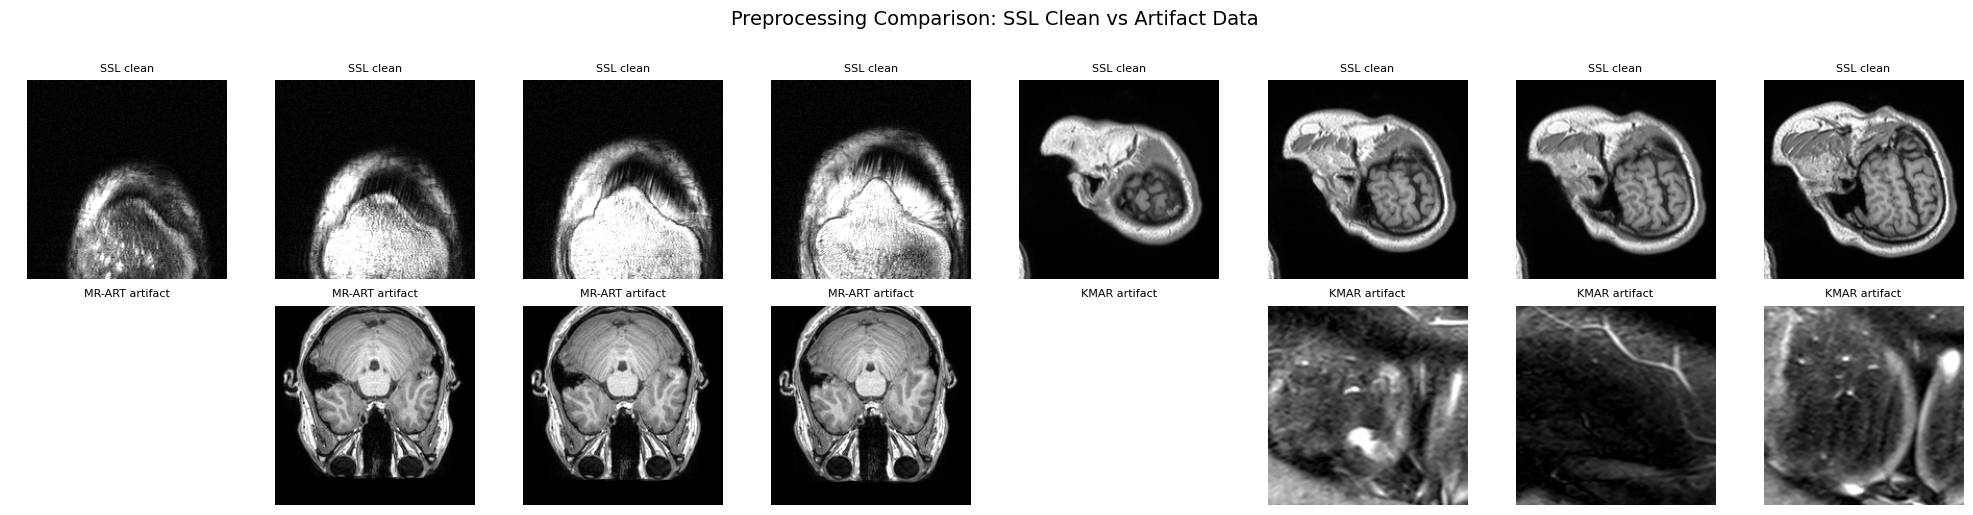

In [18]:

# ── Visual comparison: SSL clean vs artifact data ──
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("Preprocessing Comparison: SSL Clean vs Artifact Data", fontsize=14, y=1.02)

# Row 1: SSL clean samples (from shared supervised_clean_pool)
ssl_sample_paths = (clean_train_knee_dst[:4] + clean_train_brain_dst[:4])
for i, p in enumerate(ssl_sample_paths):
    if os.path.exists(p):
        img = np.load(p)
        axes[0][i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0][i].set_title('SSL clean', fontsize=8)
    axes[0][i].axis('off')

# Row 2: Artifact samples — mix of MR-ART and KMAR
artifact_samples = (mrart_artifact_saved[:4] + kmar_artifact_saved[:4])
for i, p in enumerate(artifact_samples):
    if os.path.exists(p):
        img = np.load(p)
        axes[1][i].imshow(img, cmap='gray', vmin=0, vmax=1)
    tag = 'MR-ART' if i < 4 else 'KMAR'
    axes[1][i].set_title(f'{tag} artifact', fontsize=8)
    axes[1][i].axis('off')

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_ROOT, 'preprocessing_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


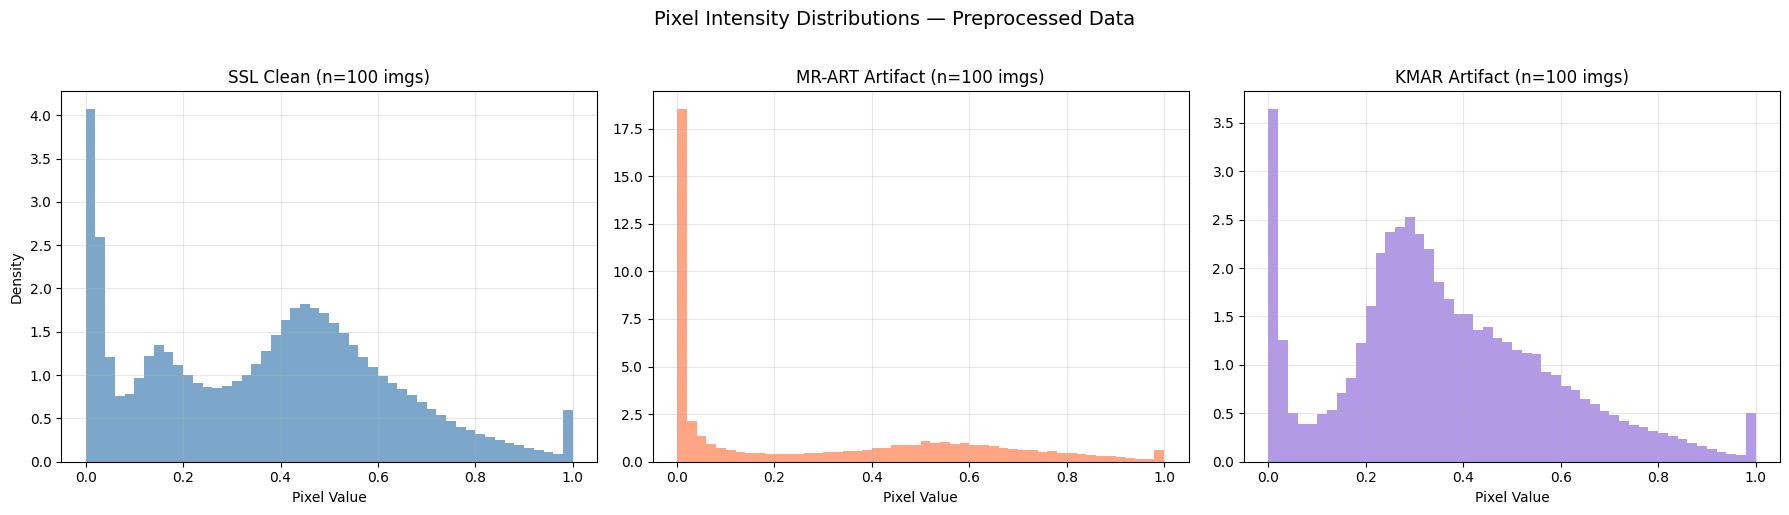

In [19]:

# ── Pixel intensity distributions ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pixel Intensity Distributions — Preprocessed Data', fontsize=14, y=1.02)

def sample_pixel_values(paths, n_images=100):
    vals = []
    for p in paths[:n_images]:
        if os.path.exists(p):
            vals.append(np.load(p).flatten())
    return np.concatenate(vals) if vals else np.array([])

# SSL clean (from shared supervised_clean_pool)
ssl_clean_all_train = clean_train_knee_dst + clean_train_brain_dst
ssl_vals = sample_pixel_values(ssl_clean_all_train, 100)
if len(ssl_vals):
    axes[0].hist(ssl_vals, bins=50, alpha=0.7, color='steelblue', density=True)
    axes[0].set_title(f'SSL Clean (n={min(100, len(ssl_clean_all_train))} imgs)')
    axes[0].set_xlabel('Pixel Value'); axes[0].set_ylabel('Density')

# MR-ART artifact
mrart_vals = sample_pixel_values(mrart_artifact_saved, 100)
if len(mrart_vals):
    axes[1].hist(mrart_vals, bins=50, alpha=0.7, color='coral', density=True)
    axes[1].set_title(f'MR-ART Artifact (n={min(100, len(mrart_artifact_saved))} imgs)')
    axes[1].set_xlabel('Pixel Value')

# KMAR artifact
kmar_vals = sample_pixel_values(kmar_artifact_saved, 100)
if len(kmar_vals):
    axes[2].hist(kmar_vals, bins=50, alpha=0.7, color='mediumpurple', density=True)
    axes[2].set_title(f'KMAR Artifact (n={min(100, len(kmar_artifact_saved))} imgs)')
    axes[2].set_xlabel('Pixel Value')

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_ROOT, 'intensity_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


---
# Final Summary

In [20]:

# ══════════════════════════════════════════════
# Final Summary
# ══════════════════════════════════════════════
print("\n" + "=" * 70)
print("  ARTIFACT DATASET PREPROCESSING — FINAL SUMMARY")
print("=" * 70)

print("\n  EXPERIMENT 1: Test SSL models on real artifacts (balanced)")
print(f"    MR-ART (brain): {len(mrart_test_artifact)} artifact + {len(mrart_clean_saved)} clean")
print(f"    KMAR (knee):    {len(kmar_test_artifact)} artifact + {len(kmar_clean_saved)} clean")
print(f"    (MR-ART and KMAR artifact/clean counts are equalized)")

print(f"\n  EXPERIMENT 2: Test SSL models on simulated artifacts")
for atype, saved in sim_saved.items():
    print(f"    {atype}: {len(saved)} slices")

print(f"\n  SUPERVISED TRAINING (3 variants, self-contained .npy files, ratio={ARTIFACT_RATIO*100:.1f}%):")
for name, (cln_tr, art_tr, cln_va, art_va) in variants.items():
    n_ct, n_at, n_cv, n_av = len(cln_tr), len(art_tr), len(cln_va), len(art_va)
    rt = 100.0 * n_at / max(1, n_at + n_ct)
    rv = 100.0 * n_av / max(1, n_av + n_cv)
    print(f"    {name:<9} TRAIN clean={n_ct:>6} art={n_at:>4} ({rt:.2f}%)  "
          f"VAL clean={n_cv:>5} art={n_av:>3} ({rv:.2f}%)")

print("\n  PREPROCESSING PIPELINE:")
print(f"    Image size:    {IMG_SIZE}x{IMG_SIZE} (center crop/pad)")
print(f"    PNG/JPG norm:  per-image p{PERCENTILE_LO}/p{PERCENTILE_HI} → [0, 1]")
print(f"    .nii volume:   per-volume p{PERCENTILE_LO}/p{PERCENTILE_HI} → [0, 1] "
      f"(same as FastMRI)")
print(f"    Slice filter:  mean > {MIN_SLICE_MEAN}")
print(f"    Format:        float32 .npy")

print(f"\n  OUTPUT FILES:")
total_size = 0
total_files = 0
for root, dirs, files in os.walk(OUTPUT_ROOT):
    for f in files:
        total_size += os.path.getsize(os.path.join(root, f))
        total_files += 1
print(f"    Location:   {OUTPUT_ROOT}")
print(f"    Files:      {total_files}")
print(f"    Total size: {total_size / 1e9:.2f} GB")

print("\n  DIRECTORY STRUCTURE:")
for root, dirs, files in os.walk(OUTPUT_ROOT):
    level = root.replace(OUTPUT_ROOT, '').count(os.sep)
    indent = '    ' + '  ' * level
    npy = [f for f in files if f.endswith('.npy')]
    npz = [f for f in files if f.endswith('.npz')]
    other = [f for f in files if not f.endswith(('.npy', '.npz'))]
    parts = []
    if npy:   parts.append(f"{len(npy)} .npy")
    if npz:   parts.append(f"{len(npz)} .npz")
    if other: parts.append(f"{len(other)} other")
    info = f" ({', '.join(parts)})" if parts else ""
    print(f"{indent}{os.path.basename(root)}/{info}")



  ARTIFACT DATASET PREPROCESSING — FINAL SUMMARY

  EXPERIMENT 1: Test SSL models on real artifacts (balanced)
    MR-ART (brain): 6881 artifact + 2960 clean
    KMAR (knee):    6881 artifact + 2960 clean
    (MR-ART and KMAR artifact/clean counts are equalized)

  EXPERIMENT 2: Test SSL models on simulated artifacts
    noisy: 1677 slices
    motion: 559 slices
    blurred: 1677 slices

  SUPERVISED TRAINING (3 variants, self-contained .npy files, ratio=7.5%):
    knee      TRAIN clean= 12864 art= 771 (5.65%)  VAL clean= 3264 art=193 (5.58%)
    brain     TRAIN clean= 12864 art= 771 (5.65%)  VAL clean= 3264 art=193 (5.58%)
    combined  TRAIN clean= 25728 art=1544 (5.66%)  VAL clean= 6528 art=386 (5.58%)

  PREPROCESSING PIPELINE:
    Image size:    192x192 (center crop/pad)
    PNG/JPG norm:  per-image p1/p99 → [0, 1]
    .nii volume:   per-volume p1/p99 → [0, 1] (same as FastMRI)
    Slice filter:  mean > 0.01
    Format:        float32 .npy

  OUTPUT FILES:
    Location:   /kaggle

In [22]:
import kagglehub

handle = 'kaustubhratna/mrartifact'
local_dataset_dir = '/kaggle/working/artifact_data'

# Create a new dataset
kagglehub.dataset_upload(handle, local_dataset_dir)

# You can then create a new version of this dataset and include version notes.
kagglehub.dataset_upload(handle, local_dataset_dir, version_notes='improved data')

# You can also specify a list of patterns for files/dirs to ignore.
# These patterns are combined with 'kagglehub.datasets.DEFAULT_IGNORE_PATTERNS'
# to determine which files and directories to exclude. 
# To ignore entire directories, include a trailing slash (/) in the pattern.
kagglehub.dataset_upload(handle, local_dataset_dir, ignore_patterns=["original/", "*.tmp"])


Uploading Dataset https://api.kaggle.com/datasets/kaustubhratna/mrartifact ...
More than 50 files detected, creating a zip archive...
Starting upload for file /tmp/tmp55_q8mkb/archive.zip


Uploading: 100%|██████████| 8.86G/8.86G [02:06<00:00, 69.8MB/s]

Upload successful: /tmp/tmp55_q8mkb/archive.zip (8GB)


Your dataset has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kaustubhratna/mrartifact
Uploading Dataset https://api.kaggle.com/datasets/kaustubhratna/mrartifact ...
More than 50 files detected, creating a zip archive...
Starting upload for file /tmp/tmpj43_xo35/archive.zip


Uploading: 100%|██████████| 8.86G/8.86G [02:10<00:00, 67.8MB/s]

Upload successful: /tmp/tmpj43_xo35/archive.zip (8GB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kaustubhratna/mrartifact
Uploading Dataset https://api.kaggle.com/datasets/kaustubhratna/mrartifact ...
More than 50 files detected, creating a zip archive...
Starting upload for file /tmp/tmpwnf617d4/archive.zip


Uploading: 100%|██████████| 8.86G/8.86G [02:03<00:00, 71.5MB/s]

Upload successful: /tmp/tmpwnf617d4/archive.zip (8GB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kaustubhratna/mrartifact
